## 🚀 Advanced Analysis & Final Insights

### 🎯 Objective
To apply advanced techniques such as segmentation, cohort analysis, and distribution analysis to derive high-impact business insights.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [10]:
df = pd.read_csv("/Users/hp/Documents/ASTU/CSEC_Projects/DataScience/telco-churn-analysis/data/raw/cleaned_telco.csv")
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,AvgMonthlySpend,Churn_numeric
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,29.850000,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,One year,No,Mailed check,56.95,1889.50,0,55.573529,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,54.075000,0
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,40.905556,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,75.825000,0


### 📊 Percentile Analysis of Monthly Charges

In [11]:
df['MonthlyCharges'].describe(percentiles=[0.25, 0.5, 0.75, 0.9])

count    7032.000000
mean       64.798208
std        30.085974
min        18.250000
25%        35.587500
50%        70.350000
75%        89.862500
90%       102.645000
max       118.750000
Name: MonthlyCharges, dtype: float64

Customers in the top 10% of monthly charges represent a high-value segment that may require targeted retention strategies.

### 💎 High-Value Customer Identification

In [12]:
high_value = df[df['MonthlyCharges'] > df['MonthlyCharges'].quantile(0.75)]
high_value['Churn'].value_counts(normalize=True)

Churn
0    0.671217
1    0.328783
Name: proportion, dtype: float64

High-value customers show a significant churn proportion, indicating potential revenue loss risk.

### 📆 Cohort Analysis Based on Tenure

In [13]:
df['TenureGroup'] = pd.cut(df['tenure'], bins=[0,12,24,48,72], 
                          labels=['0-12','12-24','24-48','48-72'])

cohort = pd.crosstab(df['TenureGroup'], df['Churn'], normalize='index') * 100
cohort

Churn,0,1
TenureGroup,,
0-12,52.321839,47.678161
12-24,71.289062,28.710938
24-48,79.611041,20.388959
48-72,90.486824,9.513176


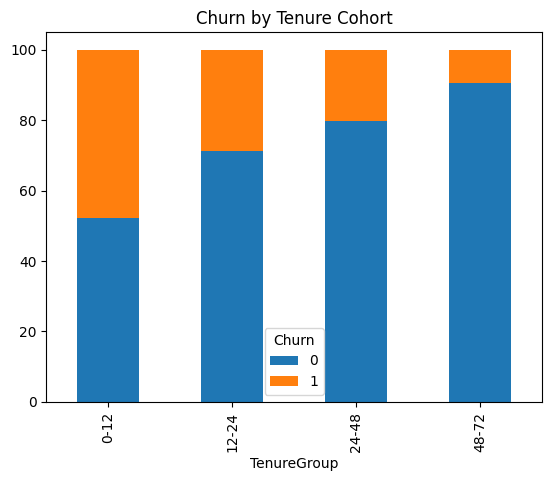

In [14]:
cohort.plot(kind='bar', stacked=True)
plt.title("Churn by Tenure Cohort")
plt.show()

Customers in their **first 12 months** show the **highest churn rates**, with nearly half leaving during this period.  
The stacked bar chart clearly illustrates how churn steadily declines as tenure increases — by 4–6 years, churn drops to under 10%.  

👉 This highlights that the **early stage of the customer lifecycle is the most critical**. Strong onboarding and engagement strategies during the first year can significantly improve retention and help move customers into lower‑risk, long‑term cohorts.


### ⚠️ Risk Segmentation

In [15]:
df['RiskLevel'] = np.where(
    (df['tenure'] < 12) & (df['MonthlyCharges'] > 70),
    'High Risk',
    'Low Risk'
)

pd.crosstab(df['RiskLevel'], df['Churn'], normalize='index') * 100

Churn,0,1
RiskLevel,,
High Risk,31.189320,68.810680
Low Risk,79.027062,20.972938


Customers with **low tenure** (newer to the company) and **high monthly charges** are at the greatest risk of churn.
This combination suggests that new customers who face higher costs may feel less committed and more likely to leave early.

Targeted retention strategies — such as discounts, personalized offers, or stronger onboarding support — are essential to reduce churn in this vulnerable group.


## 🧠 Combined Factors Impact

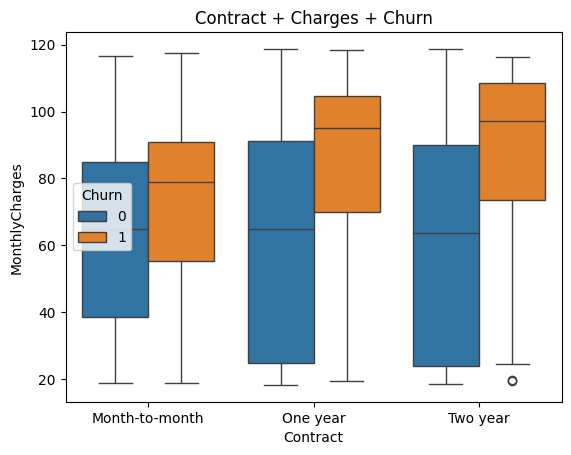

In [16]:
sns.boxplot(x='Contract', y='MonthlyCharges', hue='Churn', data=df)
plt.title("Contract + Charges + Churn")
plt.show()

High monthly charges drive churn **primarily among month‑to‑month customers**, revealing strong pricing sensitivity in this segment.  
In contrast, customers on longer contracts show much lower churn despite similar charges, indicating that **contract type moderates the impact of pricing**.  

--> This suggests that retention efforts should focus on **pricing strategies and value communication for month‑to‑month customers**, while contract customers benefit more from loyalty and long‑term engagement programs.


## 🎯 Final Insights & Conclusion

### 🔑 Key Findings

1. Early-stage customers are most likely to churn  
2. High monthly charges increase churn probability  
3. Contract type strongly influences customer retention  
4. Payment method affects customer behavior  
5. High-value customers are at risk of churn  

### 🚀 Business Recommendations

- Improve onboarding experience  
- Encourage long-term contracts  
- Offer pricing incentives  
- Target high-risk customers proactively  

#### In general this analysis demonstrates how combining multiple factors provides deeper insights than analyzing variables individually.